# 5 · Are some reviewers systematically inconsistent?

If inconsistency were pure chance, such as a misclick or a model error, a reviewer's inconsistent
reviews would be scattered at random. If some people systematically use stars differently from their
words, a reviewer who wrote one inconsistent review should be **more likely than chance** to write
another.

**Limitation.** Most All_Beauty reviewers wrote a single review in this category (notebook 1). All
tests below therefore use the minority of reviewers with **at least two** 1–2★ or 4–5★ reviews.

**Tests**

1. **Leave-one-out concordance.** Is a review more likely to be inconsistent when the same reviewer's
   *other* reviews include an inconsistent one?
2. **Permutation null.** How much concordance would we expect without any reviewer effect? We shuffle
   the inconsistency flags across reviews **within strata** and recompute. The first null keeps star
   ratings fixed. The second also fixes length, verified status, title and period. It asks whether
   clustering remains beyond the *kinds* of reviews a person writes.
3. **Prior-only prediction.** Does a reviewer's *earlier* inconsistency predict the next review, after
   controls? This test is strictly forward in time.
4. **Within-reviewer rating–sentiment alignment** for reviewers with 5 or more reviews.

In [1]:
import sys

sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from common import (AXIS, BLUE, INK_2, MUTED, SURFACE, load, ratio_table, savefig, set_style,
                    spearman, wilson)

set_style()
df = load(columns=["review_id", "user_id", "rating", "polar_rating", "inconsistent", "direction",
                   "word_count", "log_words", "verified_purchase", "has_title", "has_images",
                   "has_contrast", "year", "helpful_vote", "text_score", "user_n_reviews",
                   "user_other_polar", "user_loo_incons_rate", "user_prior_incons_rate"])
polar = df[df.polar_rating].copy()
rep = polar[polar.user_other_polar > 0].copy().reset_index(drop=True)
print(f"polar reviews: {len(polar):,}")
print(f"  by reviewers with ≥2 polar reviews: {len(rep):,} ({len(rep) / len(polar):.1%}) "
      f"from {rep.user_id.nunique():,} reviewers")
print(f"  inconsistency rate in this subset: {rep.inconsistent.mean():.2%} (all polar: {polar.inconsistent.mean():.2%})")

polar reviews: 638,532
  by reviewers with ≥2 polar reviews: 90,228 (14.1%) from 37,109 reviewers
  inconsistency rate in this subset: 1.66% (all polar: 1.79%)


## 1 · Leave-one-out concordance

In [2]:
rep["other_inconsistent"] = rep.user_loo_incons_rate > 0
conc = rep.groupby("other_inconsistent").inconsistent.agg(k="sum", n="size")
conc["rate"], conc["lo"], conc["hi"] = wilson(conc.k, conc.n)
observed_rr = conc.loc[True, "rate"] / conc.loc[False, "rate"]
print(f"risk ratio: {observed_rr:.2f}")
conc.round(4)

risk ratio: 1.97


,k,n,rate,lo,hi
other_inconsistent,,,,,
False,1391,86710,0.0160,0.0152,0.0169
True,111,3518,0.0316,0.0263,0.0379


## 2 · Permutation null

We run 1,000 permutations under each null. Each one shuffles the inconsistency flags within strata,
keeping every reviewer's set of reviews fixed, and records the resulting risk ratio.

,observed RR,null mean RR,null 95% range,permutation p
stars only,1.966841,1.252347,0.89–1.62,0.000999
stars × length × verified × title × period,1.966841,1.128999,0.78–1.50,0.000999


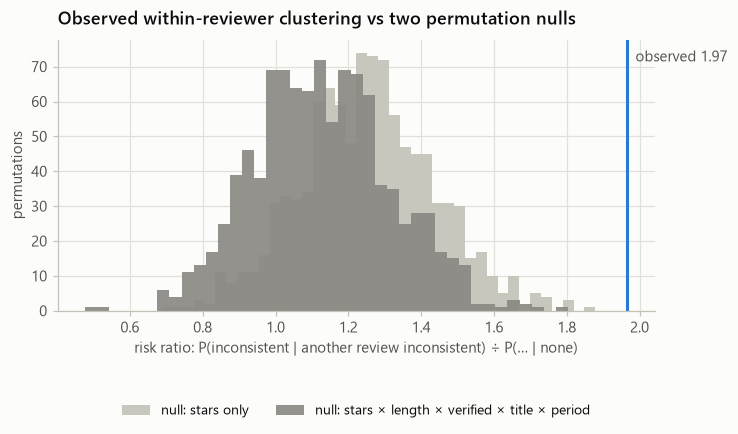

In [3]:
uid = pd.factorize(rep.user_id)[0]
flags = rep.inconsistent.to_numpy().astype(float)


def risk_ratio(f):
    other = np.bincount(uid, weights=f)[uid] - f
    return f[other > 0].mean() / f[other == 0].mean()


def null_distribution(strata, n_perm=1000, seed=0):
    rng = np.random.default_rng(seed)
    groups = [np.flatnonzero(strata == s) for s in np.unique(strata)]
    out = np.empty(n_perm)
    for i in range(n_perm):
        f = flags.copy()
        for idx in groups:
            f[idx] = flags[rng.permutation(idx)]
        out[i] = risk_ratio(f)
    return out


length_q = pd.qcut(rep.word_count.rank(method="first"), 5, labels=False).to_numpy()
period = np.digitize(rep.year, [2017, 2020])
strata_star = rep.rating.to_numpy().astype(int)
strata_full = pd.factorize(pd.Series(list(zip(strata_star, length_q, rep.verified_purchase,
                                              rep.has_title, period))))[0]

nulls = {"stars only": null_distribution(strata_star),
         "stars × length × verified × title × period": null_distribution(strata_full)}
perm = pd.DataFrame({name: {"observed RR": observed_rr, "null mean RR": n.mean(),
                            "null 95% range": f"{np.percentile(n, 2.5):.2f}–{np.percentile(n, 97.5):.2f}",
                            "permutation p": (1 + (n >= observed_rr).sum()) / (1 + len(n))}
                     for name, n in nulls.items()}).T

fig, ax = plt.subplots(figsize=(7, 3.2))
for (name, n), color in zip(nulls.items(), [AXIS, MUTED]):
    ax.hist(n, bins=40, color=color, alpha=0.9, label=f"null: {name}")
ax.axvline(observed_rr, color=BLUE, linewidth=2)
ax.text(observed_rr, ax.get_ylim()[1] * 0.92, f"  observed {observed_rr:.2f}", color=INK_2)
ax.set_xlabel("risk ratio: P(inconsistent | another review inconsistent) ÷ P(… | none)")
ax.set_ylabel("permutations")
ax.set_title("Observed within-reviewer clustering vs two permutation nulls")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2)
savefig(fig, "05_permutation_null")
perm

### Observed vs expected number of inconsistent reviews per reviewer

This view covers reviewers with at least 3 polar reviews. The expected counts are averaged over 200
permutations of the full-strata null. With a reviewer effect, the observed distribution has **more
reviewers at 0 and at 2 or more**, and fewer at exactly 1, than the null predicts. That pattern is
overdispersion.

The pattern is there, but in absolute terms it is small: a handful of extra reviewers at 2+.
Inconsistency is rare, so even a doubled risk yields few repeat-inconsistent reviewers.

,observed,expected,observed ÷ expected
0,6444,6430.8,1.00
1,382,399.4,0.96
2,23,19.5,1.18
3+,3,2.3,1.28


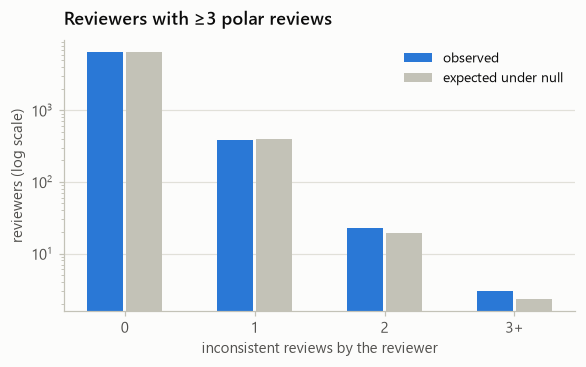

In [4]:
n_polar = np.bincount(uid)
count_labels = ["0", "1", "2", "3+"]


def per_user_counts(f):
    k = np.bincount(uid, weights=f)[n_polar >= 3]
    return np.bincount(np.minimum(k, 3).astype(int), minlength=4)


observed_counts = per_user_counts(flags)
rng = np.random.default_rng(1)
groups = [np.flatnonzero(strata_full == s) for s in np.unique(strata_full)]
sims = []
for _ in range(200):
    f = flags.copy()
    for idx in groups:
        f[idx] = flags[rng.permutation(idx)]
    sims.append(per_user_counts(f))
expected_counts = np.mean(sims, axis=0)

fig, ax = plt.subplots(figsize=(6, 3.2))
x = np.arange(4)
ax.bar(x - 0.15, observed_counts, width=0.28, color=BLUE, label="observed")
ax.bar(x + 0.15, expected_counts, width=0.28, color=AXIS, label="expected under null")
ax.set_xticks(x, count_labels)
ax.set_yscale("log")
ax.set_xlabel("inconsistent reviews by the reviewer")
ax.set_ylabel("reviewers (log scale)")
ax.set_title("Reviewers with ≥3 polar reviews")
ax.legend()
ax.grid(axis="x", visible=False)
savefig(fig, "05_observed_vs_expected")
pd.DataFrame({"observed": observed_counts, "expected": expected_counts.round(1),
              "observed ÷ expected": (observed_counts / expected_counts).round(2)}, index=count_labels)

## 3 · Prior-only prediction with controls

This model uses reviews whose author had at least one earlier polar review in the category. The
predictor is whether any of those earlier reviews were inconsistent. Controls cover the star rating
and the review features that notebook 4 found predictive.

In [5]:
prior = polar[polar.user_prior_incons_rate.notna()].copy()
prior["prior_inconsistent"] = (prior.user_prior_incons_rate > 0).astype(int)
for c in ["inconsistent", "verified_purchase", "has_title", "has_images", "has_contrast"]:
    prior[c] = prior[c].astype(int)
prior["z_log_words"] = (prior.log_words - prior.log_words.mean()) / prior.log_words.std()
prior["year_c"] = prior.year.clip(lower=2012)  # pool the sparse early years
fit = smf.logit("inconsistent ~ prior_inconsistent + C(rating) + z_log_words + verified_purchase"
                " + has_title + has_images + has_contrast + C(year_c)", prior).fit(disp=0)
print(f"n = {int(fit.nobs):,} reviews with a prior polar review by the same author")
ratio_table(fit).loc[["prior_inconsistent", "z_log_words", "has_contrast"]].round(3)

n = 53,119 reviews with a prior polar review by the same author


,odds_ratio,lo,hi,p
prior_inconsistent,1.799,1.353,2.392,0.000
z_log_words,0.991,0.898,1.094,0.861
has_contrast,2.048,1.736,2.415,0.000


## Who are the repeat-inconsistent reviewers?

The comparison covers reviewers with at least 3 polar reviews, grouped by how many of those reviews
were inconsistent.

In [6]:
u = (rep.assign(five=rep.rating == 5, one=rep.rating == 1)
        .groupby("user_id")
        .agg(polar_reviews=("inconsistent", "size"), inconsistent=("inconsistent", "sum"),
             mean_rating=("rating", "mean"), share_5_star=("five", "mean"), share_1_star=("one", "mean"),
             median_words=("word_count", "median"), verified=("verified_purchase", "mean"),
             mean_helpful=("helpful_vote", "mean"), has_title=("has_title", "mean")))
u = u[u.polar_reviews >= 3]
u["group"] = pd.cut(u.inconsistent, [-1, 0, 1, np.inf], labels=["never", "once", "2+ times"])
profile = u.groupby("group", observed=True).agg(
    reviewers=("polar_reviews", "size"), polar_reviews=("polar_reviews", "mean"),
    mean_rating=("mean_rating", "mean"), share_5_star=("share_5_star", "mean"),
    share_1_star=("share_1_star", "mean"), median_words=("median_words", "median"),
    verified=("verified", "mean"), mean_helpful=("mean_helpful", "mean"), has_title=("has_title", "mean"))
profile.round(3)

,reviewers,polar_reviews,mean_rating,share_5_star,share_1_star,median_words,verified,mean_helpful,has_title
group,,,,,,,,,
never,6444,4.171,4.288,0.691,0.101,32.00,0.716,1.126,0.921
once,382,6.251,3.749,0.490,0.149,36.50,0.712,1.018,0.931
2+ times,26,17.192,3.634,0.384,0.043,44.25,0.503,3.820,0.916


In [7]:
# Direction mix of the repeat-inconsistent reviewers' inconsistent reviews
repeat_users = u.index[u.group == "2+ times"]
rep[rep.user_id.isin(repeat_users) & rep.inconsistent].direction.value_counts(normalize=True).round(3)

direction
positive text, low stars     0.564
negative text, high stars    0.436
Name: proportion, dtype: float64

## 4 · Within-reviewer alignment of stars and sentiment

For each reviewer with 5 or more reviews whose ratings vary, we compute the Spearman correlation
between their stars and their text sentiment across their own reviews. This uses all reviews,
including 3★. A reviewer whose stars follow their words has ρ near 1. A value of ρ ≤ 0 means their
stars carry no information about, or run against, what they write.

reviewers: 1,222; median within-reviewer ρ = 0.65; share with ρ ≤ 0: 8.0%; pooled ρ across all reviews: 0.71


count    1222.000
mean        0.564
std         0.317
min        -0.866
25%         0.408
50%         0.655
75%         0.783
max         0.986
dtype: float64

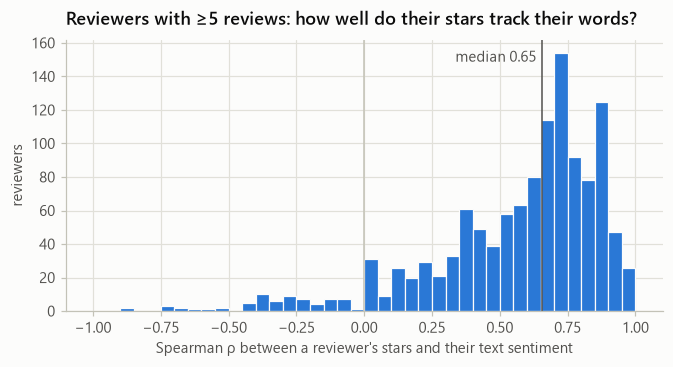

In [8]:
all_rev = df[df.user_n_reviews >= 5]
rho = (all_rev.groupby("user_id")
              .filter(lambda g: g.rating.nunique() > 1 and len(g) >= 5)
              .groupby("user_id")[["rating", "text_score"]]
              .apply(lambda g: spearman(g.rating, g.text_score)))
print(f"reviewers: {len(rho):,}; median within-reviewer ρ = {rho.median():.2f}; "
      f"share with ρ ≤ 0: {(rho <= 0).mean():.1%}; pooled ρ across all reviews: "
      f"{spearman(df.rating, df.text_score):.2f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(rho.dropna(), bins=np.linspace(-1, 1, 41), color=BLUE, edgecolor=SURFACE, linewidth=0.8)
ax.axvline(0, color=AXIS, linewidth=1)
ax.axvline(rho.median(), color=INK_2, linewidth=1)
ax.text(rho.median() - 0.02, ax.get_ylim()[1] * 0.92, f"median {rho.median():.2f}", color=INK_2, ha="right")
ax.set_xlabel("Spearman ρ between a reviewer's stars and their text sentiment")
ax.set_ylabel("reviewers")
ax.set_title("Reviewers with ≥5 reviews: how well do their stars track their words?")
savefig(fig, "05_within_reviewer_rho")
rho.describe().round(3)

### Is the low-ρ tail more than small-sample noise?

With five to ten reviews per reviewer, some correlations of ρ ≤ 0 happen by chance. The null keeps
every reviewer's star ratings. It replaces the text score of each review with the score of a
**random review with the same star rating** from the whole dataset, then recomputes ρ, 20 times over.
That gives the distribution to expect if every reviewer's words related to their stars exactly as
the population's do.

In [9]:
own = df[df.user_id.isin(rho.index)][["user_id", "rating", "text_score"]].copy()
pools = {r: df.loc[df.rating == r, "text_score"].to_numpy() for r in sorted(df.rating.unique())}
rng = np.random.default_rng(0)
null_share, null_median = [], []
for _ in range(20):
    fake = np.empty(len(own))
    for r, pool in pools.items():
        idx = np.flatnonzero(own.rating.to_numpy() == r)
        fake[idx] = rng.choice(pool, len(idx))
    null_rho = (own.assign(text_score=fake).groupby("user_id")[["rating", "text_score"]]
                   .apply(lambda g: spearman(g.rating, g.text_score)))
    null_share.append((null_rho <= 0).mean())
    null_median.append(null_rho.median())
pd.DataFrame({"observed": {"share with ρ ≤ 0": (rho <= 0).mean(), "median ρ": rho.median()},
              "null mean": {"share with ρ ≤ 0": np.mean(null_share), "median ρ": np.mean(null_median)},
              "null range (20 draws)": {"share with ρ ≤ 0": f"{min(null_share):.3f}–{max(null_share):.3f}",
                                        "median ρ": f"{min(null_median):.3f}–{max(null_median):.3f}"}}).round(3)

,observed,null mean,null range (20 draws)
share with ρ ≤ 0,0.080,0.077,0.063–0.087
median ρ,0.655,0.634,0.612–0.655
